# Intro
The following notebook examines the possibility of fitting a machine learning model to signals received as IQ pairs. It attempts to implicitly learn a constellation plot and a set of decision boundaries for decoding the transmitted symbols, without explicitly being given either. By doing so, it can then learn the modulation scheme and predict all symbols sent. The model is trained on a dataset of randomly generated signals with known modulation schemes, and then tested on new signals with various impairments (channel noise, signal interference, low-pass filtering) to evaluate its robustness.

This project has three parts: signal and impairment generation (when I use impairment, I mean any sort of distraction for the signal), model creation, training, and analysis, and model iteration. Generation deals with creating a viable harness to provide the model with data. Model creation, training, and analysis includes the initial model and its performance analysis. Model iteration seeks to improve upon the model to support impaired signals.

Prerequisites if you want to run the notebook (not recommended, training the big model on Apple Silicon takes about an hour!): torch, numpy, scipy, scikit-learn.

The next few cells are large blocks of code written to support the following experiments, so bear with me!

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

### Lookup Tables
In order to generate labeled data, I needed to come up with a clever way to map IQ pairs to global class indices. For example, (1,-1) in BPSK maps to the bit pattern "1", which is class index 1 in the global softmax. But (1,-1) in QPSK maps to "11", which is class index 5 globally (2 for the QPSK offset + 3 for the bit pattern). I created a lookup table for each scheme that maps (I, Q) pairs to their global class indices, and then used per-scheme normalization to convert raw amplitude values to table indices. This way, I can directly generate the correct labels for any given IQ signal. This part isn't super important to the idea of the project and was more of a pain than anything else, but it is important for the data generation process and is a neat example of how to handle multiple schemes with a shared output space. I've included docstrings where I think they are useful to follow along.

Just to state it, this whole process would have been much easier with dictionaries. However, to challenge myself, I wanted to come up with an almost entirely vectorized approach to speed things up in a hypothetical real world environment (hence the numpy tables rather than dictionaries).

In [58]:
SCHEMES = ("BPSK", "QPSK", "16QAM", "64QAM")
BITS_PER_SYMBOL = {"BPSK": 1, "QPSK": 2, "16QAM": 4, "64QAM": 6}
TOTAL_CLASSES = 86  # 2 + 4 + 16 + 64

# cumulative offsets into the shared 86-class softmax vector
SCHEME_OFFSETS = {}
offset = 0
for scheme in SCHEMES:
    SCHEME_OFFSETS[scheme] = offset
    offset += 2 ** BITS_PER_SYMBOL[scheme]


def _gray_code(n_bits):
    # standard reflected Gray code for n_bits
    return [i ^ (i >> 1) for i in range(2 ** n_bits)]


def _make_levels(order):
    # odd-integer amplitude levels, e.g. order=4 -> (-3, -1, 1, 3)
    return tuple(2 * i - (order - 1) for i in range(order))


def _amplitude_bounds(levels):
    # integer bounds for rng.integers() that produce the correct levels after 2*x+1 transform in the IQGenerator
    n = len(levels)
    if n == 1:
        return (0, 1)
    return (-n // 2, n // 2)


def _normalization(levels):
    # (offset, step) to convert amplitude values to array indices
    off = -levels[0]
    step = (levels[1] - levels[0]) if len(levels) > 1 else 1
    return off, step


# per-scheme constellation definitions to make things easier
SCHEME_DEFS = {
    "BPSK": {
        "i_levels": (-1, 1),
        "q_levels": (0,),
        "symbol_map": {(-1, 0): 0b0, (1, 0): 0b1},
    },
    "QPSK": {
        "i_levels": (-1, 1),
        "q_levels": (-1, 1),
        "symbol_map": {(-1, -1): 0b00, (-1, 1): 0b01, (1, 1): 0b11, (1, -1): 0b10},
    },
}

# 16QAM and 64QAM use standard Gray-coded square constellations, as seems to be done in practice
for name, bits_per_axis in [("16QAM", 2), ("64QAM", 3)]:
    order = 2 ** bits_per_axis
    levels = _make_levels(order)
    gray = _gray_code(bits_per_axis)
    SCHEME_DEFS[name] = {
        "i_levels": levels,
        "q_levels": levels,
        "symbol_map": {
            (i, q): (i_bits << bits_per_axis) | q_bits
            for i, i_bits in zip(levels, gray)
            for q, q_bits in zip(levels, gray)
        },
    }


def _build_lookup_table(symbol_map, i_levels, q_levels, global_offset):
    # map (I, Q) constellation points to global class indices
    i_off, i_step = _normalization(i_levels)
    q_off, q_step = _normalization(q_levels)

    table = np.zeros((len(i_levels), len(q_levels)), dtype=np.uint8)
    for (i, q), bits in symbol_map.items():
        table[(i + i_off) // i_step, (q + q_off) // q_step] = bits + global_offset
    return table


# build all derived lookup structures
scheme_to_index_table_map = {}
SCHEME_NORMALIZATION = {}
scheme_to_high_low_map = {}

for scheme, defn in SCHEME_DEFS.items():
    i_levels, q_levels = defn["i_levels"], defn["q_levels"]

    scheme_to_index_table_map[scheme] = _build_lookup_table(
        defn["symbol_map"], i_levels, q_levels, SCHEME_OFFSETS[scheme]
    )

    i_off, i_step = _normalization(i_levels)
    q_off, q_step = _normalization(q_levels)
    SCHEME_NORMALIZATION[scheme] = (i_off, i_step, q_off, q_step)

    scheme_to_high_low_map[scheme] = [_amplitude_bounds(i_levels), _amplitude_bounds(q_levels)]


# global index -> binary symbol string ("0", "01", "0010", etc.)
index_to_symbol = np.array([
    format(i, f'0{BITS_PER_SYMBOL[scheme]}b')
    for scheme in SCHEMES
    for i in range(2 ** BITS_PER_SYMBOL[scheme])
], dtype='<U6')


def format_bit_string(index_list: np.ndarray) -> str:
    return ' '.join(index_to_symbol[index_list].astype(str))

### Dataset
To use Pytorch, we need to define a class that will hold our data. This is a simple wrapper that takes in either a numpy array or a Pytorch tensor and stores the data for Pytorch to use later on.

In [59]:
from typing import Union

import torch
from numpy import ndarray
from torch.utils.data import Dataset, Subset, ConcatDataset


class IQDataset(Dataset):
    def __init__(self, data: Union[ndarray, torch.Tensor], labels: Union[ndarray, torch.Tensor], transform=None):
        # initialize dataset from IQ data array and labels
        self.data: torch.Tensor = torch.from_numpy(data) if isinstance(data, ndarray) else data
        self.labels: torch.Tensor = torch.from_numpy(labels) if isinstance(labels, ndarray) else labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

## Signal Impairments
Later, we will try to examine how the model generalizes to noise, interference and filter effects. The functions below allow me to add impairments to a single signal for a quick test, or to an entire dataset for training and/or final testing validation.
1. Noise: White Gaussian noise is added to the signal, with power derived from the signal's measured power and a target SNR (signal-to-noise ratio). The noise is split equally across I and Q channels.
2. Interference: A scaled interfering signal is added directly to the IQ samples, modeling a second transmitter whose signal is received simultaneously. A ratio controls the strength of the interference relative to the original signal.
3. Low-pass filter: A 4th-order Butterworth low-pass filter is applied along the time/symbol axis, modeling the band-limiting effect of real hardware (antennas, amplifiers, cables). As you explained, this causes adjacent symbols to bleed into each other as it acts as a moving average in the simplest case. This is purposefully difficult to handle, and I will examine a possible solution below.

In [60]:
from scipy.signal import butter, sosfilt
def add_noise_to_sample(sample, snr_db: float | None = None, rng: np.random.Generator = None):
    # add noise to a single IQ sample of shape (1, L, 2) (np.ndarray or Tensor)
    # normalize to numpy for math
    is_tensor = isinstance(sample, torch.Tensor)
    sample_np = sample.detach().cpu().numpy() if is_tensor else np.asarray(sample)

    if rng is None:
        rng = np.random.default_rng()
    if snr_db is None:
        snr_db = np.random.uniform(5, 15)

    signal_power = np.mean(np.sum(sample_np ** 2, axis=2, keepdims=True), axis=1, keepdims=True)
    noise_powers = signal_power / (10 ** (snr_db / 10))
    noise_std = np.sqrt(noise_powers / 2)
    noise = rng.normal(0, noise_std, sample_np.shape)

    noisy_np = sample_np + noise
    if is_tensor:
        return torch.from_numpy(noisy_np).type_as(sample)
    return noisy_np.astype(np.float32)


def add_interference_to_sample(sample, interference_sample, interference_ratio: float | None = None):
    # add a scaled interfering IQ sample
    is_tensor = isinstance(sample, torch.Tensor)
    sample_np = sample.detach().cpu().numpy() if is_tensor else np.asarray(sample)
    interference_np = interference_sample.detach().cpu().numpy() if isinstance(interference_sample, torch.Tensor) else np.asarray(interference_sample)

    if interference_ratio is None:
        interference_ratio = np.random.uniform(0, 0.3)

    combined_np = sample_np + interference_ratio * interference_np
    if is_tensor:
        return torch.from_numpy(combined_np).type_as(sample)
    return combined_np.astype(np.float32)


def apply_low_pass_filter_to_sample(sample):
    # apply a Butterworth low-pass filter to a single IQ sample
    is_tensor = isinstance(sample, torch.Tensor)
    sample_np = sample.detach().cpu().numpy() if is_tensor else np.asarray(sample)

    sos = butter(N=4, Wn=0.4, btype='low', analog=False, output='sos')
    filtered_np = sosfilt(sos, sample_np, axis=1)

    if is_tensor:
        return torch.from_numpy(filtered_np).type_as(sample)
    return filtered_np.astype(np.float32)

def add_noise(signal: IQDataset,
              snr_db: float = None,
              rng: np.random.Generator = None) -> IQDataset:
    # add noise to an IQ dataset
    if rng is None:
        rng = np.random.default_rng()
    if snr_db is None:
        snr_db = np.random.uniform(5, 15)

    # find signal power (as float64 for stability)
    signal_data = signal.data.numpy().astype(np.float64)
    signal_power = np.mean(np.sum(signal_data**2, axis=2, keepdims=True), axis=1, keepdims=True)

    # find noise power and std deviation
    noise_powers = signal_power / (10 ** (snr_db / 10))
    noise_std = np.sqrt(noise_powers / 2)
    noise = rng.normal(0, noise_std, signal_data.shape)

    noisy = (signal_data + noise).astype(np.float32)
    return IQDataset(noisy, signal.labels)


def add_interference(signal: IQDataset,
                     interference_signal: IQDataset,
                     interference_ratio: float = None) -> IQDataset:
    # add a scaled interfering signal to an IQ dataset
    if interference_ratio is None:
        interference_ratio = np.random.uniform(0, 0.3)

    base = signal.data.numpy().astype(np.float64)
    interferer = interference_signal.data.numpy().astype(np.float64)
    combined = (base + interference_ratio * interferer).astype(np.float32)
    return IQDataset(combined, signal.labels)


def apply_low_pass_filter(signal: IQDataset) -> IQDataset:
    # apply a Butterworth low-pass filter to an IQ dataset
    np_data = signal.data.numpy().astype(np.float64)

    # for numerical stability as you mentioned
    sos = butter(N=4, Wn=0.4, btype='low', analog=False, output='sos')
    filtered = sosfilt(sos, np_data, axis=1).astype(np.float32)

    return IQDataset(filtered, signal.labels)


### IQGenerator
A class that generates random IQ datasets representing the signal received from a transmitter. Includes:
1. A seeded NumPy random generator for reproducibility.
2. Support for multiple modulation schemes (BPSK, QPSK, 16QAM, 64QAM) with configurable distribution in generated datasets.
3. Methods to generate IQ signals and their corresponding global softmax label indices based on the modulation scheme, using the lookup tables defined above. The main method, `generate_dataset`, creates a mixed-scheme dataset according to the specified distribution, generating signals and labels for each scheme as needed.
4. Internal helper methods to compute scheme boundaries, generate boolean masks for sample assignment, and allocate arrays for IQ signals and labels
5. Single signal generation for testing purposes.

In [61]:
from typing import Literal, List, Tuple

class IQGenerator:

    def __init__(self, seed: int = 42, scheme_distribution = (0.25,0.25,0.25,0.25)):

        self.rng = np.random.default_rng(seed)
        self.scheme_distribution = scheme_distribution
        if sum(scheme_distribution) != 1 or len(scheme_distribution) != 4:
            raise ValueError("scheme_distribution must be a list of 4 floats summing to 1.")

    def _get_scheme_boundaries(self):
        # Compute cumulative probability boundaries for each modulation scheme

        bpsk_dist, qpsk_dist, sixteen_qam_dist, sixtyfour_qam_dist = self.scheme_distribution
        first_bound = bpsk_dist
        second_bound = first_bound + qpsk_dist
        third_bound = second_bound + sixteen_qam_dist
        return first_bound, second_bound, third_bound

    def _get_scheme_masks(self, num_samples=128):
        # Generate boolean masks assigning each sample to a modulation scheme

        first_bound, second_bound, third_bound = self._get_scheme_boundaries()
        uni = self.rng.random(size=(num_samples,))
        bpsk_mask = uni < first_bound
        qpsk_mask = (uni >= first_bound) & (uni < second_bound)
        stqam_mask = (uni >= second_bound) & (uni < third_bound)
        sfqam_mask = uni >= third_bound
        return bpsk_mask, qpsk_mask, stqam_mask, sfqam_mask

    def _allocate_iq_and_label_arrays(self, num_samples, length):
        # Allocate zeroed arrays for IQ signals and symbol label indices

        iq_arr = np.zeros(shape=(num_samples, length, 2), dtype=np.float32)
        symbol_indices_arr = np.zeros(shape=(num_samples, length), dtype=np.int64)
        return iq_arr, symbol_indices_arr

    def _generate_mask_scheme_pairs(self, num_samples):
        # Pair each scheme's boolean mask with its scheme name

        bpsk_mask, qpsk_mask, stqam_mask, sfqam_mask = self._get_scheme_masks(num_samples=num_samples)
        pairs: List [Tuple[ndarray, Literal["BPSK", "QPSK", "16QAM", "64QAM"]]] = [
            (bpsk_mask, "BPSK"),
            (qpsk_mask, "QPSK"),
            (stqam_mask, "16QAM"),
            (sfqam_mask, "64QAM"),
        ]
        return pairs

    def generate_signals(self, n_samples=128, length=256, seed=None, modulation_scheme: Literal["BPSK", "QPSK", "16QAM", "64QAM"] = "BPSK"):
        # Generate IQ signals by drawing random constellation points

        # in case you want to use the same generator to create different datasets
        rand = self.rng
        if seed is not None:
            rand = np.random.default_rng(seed)

        # get boundaries for samples
        i_bounds, q_bounds = scheme_to_high_low_map[modulation_scheme]
        i_low, i_high = i_bounds
        q_low, q_high = q_bounds

        i_samples = rand.integers(i_low, i_high, size=(n_samples, length))
        q_samples = rand.integers(q_low, q_high, size=(n_samples, length))

        # convert into proper format for IQ
        i_samples = 2 * i_samples + 1
        if modulation_scheme != "BPSK":
            q_samples = 2 * q_samples + 1

        # stack to create distinct channels
        return np.stack((i_samples, q_samples), axis=2).astype(np.float32)

    def generate_softmax_indices_for_signals(self, iq_signals, modulation_scheme: Literal["BPSK", "QPSK", "16QAM", "64QAM"] = "BPSK"):
        # Map IQ signal amplitudes to global softmax class indices

        index_table = scheme_to_index_table_map[modulation_scheme]
        i_offset, i_step, q_offset, q_step = SCHEME_NORMALIZATION[modulation_scheme]
        i_idx = (iq_signals[:, :, 0].astype(int) + i_offset) // i_step
        q_idx = (iq_signals[:, :, 1].astype(int) + q_offset) // q_step
        return index_table[i_idx, q_idx].astype(np.int64)

    def generate_dataset(self, num_samples=128, length=128, seed=None) -> IQDataset:
        # Generate a mixed-scheme IQDataset ready for training

        # allocate memory for the dataset
        iq_arr, symbol_indices_arr = self._allocate_iq_and_label_arrays(num_samples=num_samples, length=length)

        # map masks to schemes for generation purposes
        mask_scheme_pairs = self._generate_mask_scheme_pairs(num_samples=num_samples)

        # loop over each mask and set to a generate signal. Set labels based on the scheme
        for mask, scheme in mask_scheme_pairs:
            # number of samples to generate for this scheme is the number of True values in the mask
            count = mask.sum()
            if count == 0:
                continue
            # set those rows to IQ signals
            iq_arr[mask] = self.generate_signals(n_samples=count, length=length, modulation_scheme=scheme, seed=seed)
            symbol_indices_arr[mask] = self.generate_softmax_indices_for_signals(iq_arr[mask], modulation_scheme=scheme)

        return IQDataset(data=iq_arr, labels=symbol_indices_arr)



# for later to run tests once the model is trained
def run_scheme_test(generator,
                    model,
                    scheme: str,
                    length: int = 256,
                    seed: int = 11,
                    device: str = "cpu",
                    impairments: list[str] | None = None,
                    conv: bool = False,
                    n_samples: int = 1):
    if impairments is None:
        impairments = []

    # generate clean test signals and ground-truth indices
    test_signal_np = generator.generate_signals(
        n_samples=n_samples,
        length=length,
        modulation_scheme=scheme,
        seed=seed,
    )

    proper_indices = generator.generate_softmax_indices_for_signals(
        test_signal_np,
        modulation_scheme=scheme,
    ).flatten()

    test_signal = torch.from_numpy(test_signal_np).to(device)

    # apply impairments (order: noise -> interfere -> filter)
    if "noise" in impairments:
        test_signal = add_noise_to_sample(test_signal)

    if "interfere" in impairments:
        interference_np = generator.generate_signals(
            n_samples=n_samples,
            length=length,
            modulation_scheme=scheme,
            seed=seed + 9999,
        )
        interference = torch.from_numpy(interference_np).to(device)
        test_signal = add_interference_to_sample(test_signal, interference, interference_ratio=0.3)

    if "filter" in impairments:
        test_signal = apply_low_pass_filter_to_sample(test_signal)
        test_signal = test_signal.to(device)

    # the conv network requires a different order of arguments
    if conv:
        test_signal = test_signal.permute(0, 2, 1)  # (B, L, 2) -> (B, 2, L)

    with torch.no_grad():
        logits = model(test_signal)
        predicted_indices = logits.argmax(dim=2).cpu().numpy().flatten()

    # convert to bit strings
    proper_bit_str = format_bit_string(proper_indices)
    predicted_bit_str = format_bit_string(predicted_indices)
    proper_no_space = proper_bit_str.replace(" ", "")
    predicted_no_space = predicted_bit_str.replace(" ", "")

    # build impairment description for reporting
    if not impairments:
        impairment_desc = "No noise"
    else:
        ordered_kinds = [k for k in ["noise", "interfere", "filter"] if k in impairments]
        impairment_desc = ", ".join(ordered_kinds)

    # Report
    print(f"{scheme} Test ({impairment_desc}) \u2014 {n_samples} sample(s)")
    print("Transmitted Signal Symbols (32 MSBs):", proper_bit_str[:32])
    print("Decoded Signal Symbols (32 MSBs):    ", predicted_bit_str[:32])
    print("Bit Error Rate", sum(p != q for p, q in zip(proper_no_space, predicted_no_space)) / max(len(proper_no_space), len(predicted_no_space)))
    print("-" * 50)

### The Initial Solution: An Attention-Based Model
This classification problem is incredibly unique. Instead of receiving a sample and classifying it, we need to receive a sequence of samples and classify each one relative to the others. We need to be able to support inputs of varying lengths (signals), and we need the output to be time invariant. That is, the order of the symbols does not matter. Symbol n should affect symbol 0 as much as 0 affects n.

This type of problem naturally lends itself to some sort of attention based architecture. Attention allows each element in a sequence of vectors to influence every other regardless of their position. After every element has absorbed the context of its surroundings, we can pass the output to a simple linear block to output class predictions. A prediction is defined as an 86 entry vector, where each position corresponds to a single symbol, ranging from 0, 1, 00, 01 ... all the way to 111111. The model learns to map IQ pairs to this global symbol space, and to learn the constellation and decision boundaries implicitly through the attention mechanism and the training process.

In [62]:
class AttentionModel(nn.Module):
    def __init__(self):
        # takes in (B,2,L) and outputs (B,1,L), or simply (B,L) after squeezing
        # each (I,Q) needs to attend to all other (I,Q) pairs in their signal. the sequence is the L dimension, with the vector being [I,Q]
        super().__init__()
        # (B,2,L) -> (B,64,L) for attention
        self.embed1 = nn.Linear(2, 64)  # embed (I,Q) pairs into a higher-dimensional space
        # (B,L,64) -> (B,L,64) for attention
        self.attention1 = nn.MultiheadAttention(embed_dim=64, num_heads=8, batch_first=True, dropout=0.1) # attention computes (S,S) where each E_i,j is how much query i attends to key j. Then matmul by (S,dv), or all value vectors to take the weighted sum of values for each query. Concatenate all heads to be (S, dv*num_heads) = (S, embed_dim) since dv = embed_dim/num_heads
        self.linear1 = nn.Linear(64, 128)
        self.linear2 = nn.Linear(128, 64)
        self.attention2 = nn.MultiheadAttention(embed_dim=64, num_heads=8, batch_first=True, dropout=0.1)
        self.linear3 = nn.Linear(64, 128)
        self.linear4 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 86) # one output per possible symbol

        self.layernorm1 = nn.LayerNorm(64)
        self.layernorm2 = nn.LayerNorm(64)
        self.layernorm3 = nn.LayerNorm(64)
        self.layernorm4 = nn.LayerNorm(64)

        self.gelu = nn.GELU()

    def forward(self, x):
        x = self.embed1(x) # (B,L,64) for attention)

        x = self.layernorm1(x + self.attention1(x,x,x)[0])
        y = self.linear1(x)
        y = self.gelu(y)
        y = self.linear2(y)
        x = self.layernorm2(x + y)
        x = self.layernorm3(x + self.attention2(x,x,x)[0])
        y = self.linear3(x)
        y = self.gelu(y)
        y = self.linear4(y)
        x = self.layernorm4(x + y)
        return self.output(x)




### Training
The following cells generate a dataset, split it into training and validation sets, and then train the model for a simple 20 epochs. Hyperparameters are chosen arbitrarily.

In [63]:
from torch.utils import data

initial_generator = IQGenerator(seed=42, scheme_distribution=(0.25, 0.25, 0.25, 0.25))
initial_dataset = initial_generator.generate_dataset(num_samples=2000, length=128)
initial_train = Subset(initial_dataset, indices=range(1750))
initial_validate = Subset(initial_dataset, indices=range(1750, 2000))

base_train_dataloader = data.DataLoader(initial_train, batch_size=64, shuffle=True)
base_val_dataloader = data.DataLoader(initial_validate, batch_size=64, shuffle=False)

device = 'mps' if torch.backends.mps.is_available() else 'cpu'


In [64]:
import copy

def train(train_dataloader, val_dataloader, model, epochs=20, device=None, conv=False, best_model=False):
    # move model to target device and set up optimizer, scheduler, and loss
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    # track the best validation accuracy for early-stopping / model selection
    best_val_acc = 0.0
    best_state = None

    # record per-epoch losses for plotting
    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # training
        model.train()
        total_train_loss = 0
        for x_batch, y_batch in train_dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            # conv models expect channels-first: (B, 2, L)
            if conv:
                x_batch = x_batch.permute(0, 2, 1)

            optimizer.zero_grad()
            outputs = model(x_batch)

            # permute logits to (B, C, L) for cross-entropy which expects channel dim second
            loss = loss_fn(outputs.permute(0,2,1), y_batch)
            loss.backward()

            # clip gradients to prevent exploding updates
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_dataloader)
        train_losses.append(avg_train_loss)

        # step the cosine annealing schedule once per epoch
        scheduler.step()

        # validation
        total_loss = 0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dataloader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                if conv:
                    x_batch = x_batch.permute(0, 2, 1)

                outputs = model(x_batch)
                loss = loss_fn(outputs.permute(0,2,1), y_batch)

                # argmax over the class dim to get predicted symbol indices
                predictions = torch.argmax(outputs, dim=2)

                # accumulate correct predictions and total symbol count
                correct += (predictions == y_batch).sum().item()
                total += y_batch.numel()
                total_loss += loss.item()

        avg_loss = total_loss / len(val_dataloader)
        val_losses.append(avg_loss)
        accuracy = correct / total

        lr = scheduler.get_last_lr()[0]

        # save a deep copy of the model state if this is the best accuracy so far
        if best_model and accuracy > best_val_acc:
            best_val_acc = accuracy
            best_state = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch+1}/{epochs} | LR: {lr:.6f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {avg_loss:.4f} | Validation Accuracy: {accuracy:.4f} *best*")
        else:
            print(f"Epoch {epoch+1}/{epochs} | LR: {lr:.6f} | Training Loss: {avg_train_loss:.4f} | Validation Loss: {avg_loss:.4f} | Validation Accuracy: {accuracy:.4f}")

    # restore the best checkpoint after all epochs are done
    if best_model and best_state is not None:
        model.load_state_dict(best_state)
        print(f"\nLoaded best model with validation accuracy: {best_val_acc:.4f}")

    return model, train_losses, val_losses

In [65]:
model, base_train_losses, base_val_losses = train(model=AttentionModel(), train_dataloader=base_train_dataloader, val_dataloader=base_val_dataloader, epochs=15, device=device)

Epoch 1/15 | LR: 0.000989 | Training Loss: 2.8961 | Validation Loss: 1.8160 | Validation Accuracy: 0.6600
Epoch 2/15 | LR: 0.000957 | Training Loss: 1.2858 | Validation Loss: 0.8387 | Validation Accuracy: 0.8585
Epoch 3/15 | LR: 0.000905 | Training Loss: 0.6581 | Validation Loss: 0.4373 | Validation Accuracy: 0.9750
Epoch 4/15 | LR: 0.000835 | Training Loss: 0.3723 | Validation Loss: 0.2491 | Validation Accuracy: 0.9994
Epoch 5/15 | LR: 0.000750 | Training Loss: 0.2317 | Validation Loss: 0.1498 | Validation Accuracy: 0.9999
Epoch 6/15 | LR: 0.000655 | Training Loss: 0.1554 | Validation Loss: 0.0964 | Validation Accuracy: 1.0000
Epoch 7/15 | LR: 0.000552 | Training Loss: 0.1124 | Validation Loss: 0.0688 | Validation Accuracy: 1.0000
Epoch 8/15 | LR: 0.000448 | Training Loss: 0.0866 | Validation Loss: 0.0521 | Validation Accuracy: 1.0000
Epoch 9/15 | LR: 0.000345 | Training Loss: 0.0708 | Validation Loss: 0.0427 | Validation Accuracy: 1.0000
Epoch 10/15 | LR: 0.000250 | Training Loss: 0.

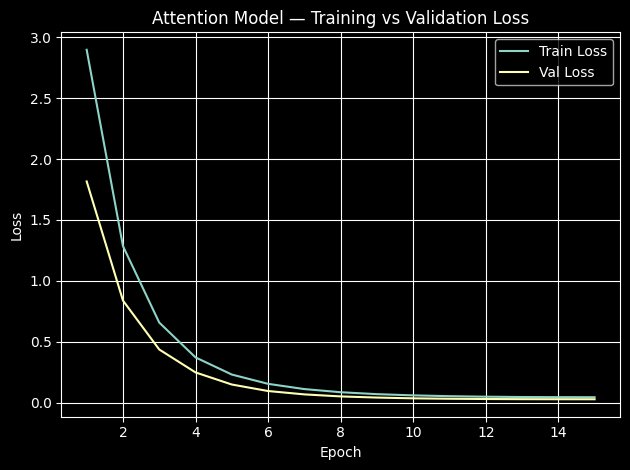

In [66]:
# plot the loss curves for training and validation
plt.figure()
plt.plot(range(1, len(base_train_losses) + 1), base_train_losses, label="Train Loss")
plt.plot(range(1, len(base_val_losses) + 1), base_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Attention Model — Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Initial Results
The model performs perfectly on the clean test signals for all modulation schemes, achieving a 100% accuracy. Let's check it out on some independently generated samples.

In [67]:
run_scheme_test(generator=initial_generator, model=model, scheme="BPSK", length=128, seed=11, impairments=[], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=model, scheme="QPSK", length=128, seed=12, impairments=[], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=model, scheme="16QAM", length=128, seed=13, impairments=[], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=model, scheme="64QAM", length=128, seed=14, impairments=[], device=device, n_samples=100)


BPSK Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 
Decoded Signal Symbols (32 MSBs):     0 0 1 0 1 1 1 0 0 0 0 1 1 0 1 0 
Bit Error Rate 0.0
--------------------------------------------------
QPSK Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 10 00 10 10 01 00 00 00 10 01 00
Decoded Signal Symbols (32 MSBs):     10 00 10 10 01 00 00 00 10 01 00
Bit Error Rate 0.0
--------------------------------------------------
16QAM Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 1001 1010 1000 0001 1001 10
Decoded Signal Symbols (32 MSBs):     1000 1001 1010 1000 0001 1001 10
Bit Error Rate 0.0
--------------------------------------------------
64QAM Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 001101 101111 111011 011010 0001
Decoded Signal Symbols (32 MSBs):     001101 101111 111011 011010 0001
Bit Error Rate 0.0
--------------------------------------------------


Perfect! 0.0 bit errors on all modulation schemes of considerable length. Now let's see how it does with some impairments. Remember, the model has never seen noise, interference, or filtering effects during training, so this will be a test of its generalization capabilities.

In [68]:
run_scheme_test(generator=initial_generator, model=model, scheme="16QAM", length=128, seed=22, impairments=["noise"], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=model, scheme="16QAM", length=128, seed=22, impairments=["interfere"], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=model, scheme="16QAM", length=128, seed=22, impairments=["filter"], device=device, n_samples=100)

16QAM Test (noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1100 0101 0101 0110 1000 0111 01
Bit Error Rate 0.4371116822986706
--------------------------------------------------
16QAM Test (interfere) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1100 0100 1101 0010 1100 0110 01
Bit Error Rate 0.5001751995328012
--------------------------------------------------
16QAM Test (filter) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1101 1101 1100 1100 1101 0111 01
Bit Error Rate 0.43642578125
--------------------------------------------------


This is a significantly worse performance, which makes sense. To account for signal impairments, we need to train the model on data to include those impairments. Let's train 3 new models, each with a different impairment added to the training data, and then test them on the same impaired signals to see how they do. Note that interference, noise, and filtering are all a consequence of sending the signal through a channel. We will consider them all together once we can get a baseline on them seperately.

In [36]:
from sklearn.model_selection import train_test_split

interference_dataset = initial_generator.generate_dataset(2000, 128, seed=9999) # generate a dataset to use as interferance for the test set
new_dataset = initial_generator.generate_dataset(2000, 128, seed=1111)

# add noise to original dataset
noise_dataset = add_noise(initial_dataset, snr_db=10)

# interfere with original
interfered_dataset = add_interference(initial_dataset, interference_dataset, interference_ratio=0.1)

# apply a low pass filter
filtered_dataset = apply_low_pass_filter(initial_dataset)

# concat clean + impaired, then split into train/val
noise_combined = ConcatDataset([new_dataset, noise_dataset])
interfere_combined = ConcatDataset([new_dataset, interfered_dataset])
filter_combined = ConcatDataset([new_dataset, filtered_dataset])

train_idx, val_idx = train_test_split(range(len(noise_combined)), test_size=0.125, random_state=11)

# train the models
noisy_model, _, _ = train(model=AttentionModel(), train_dataloader=data.DataLoader(Subset(noise_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(noise_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device)
interfered_model, _, _ = train(model=AttentionModel(), train_dataloader=data.DataLoader(Subset(interfere_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(interfere_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device)
filtered_model, _, _ = train(model=AttentionModel(), train_dataloader=data.DataLoader(Subset(filter_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(filter_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device)

Epoch 1/15 | LR: 0.000989 | Training Loss: 2.2715 | Validation Loss: 1.0605 | Validation Accuracy: 0.7582
Epoch 2/15 | LR: 0.000957 | Training Loss: 0.8167 | Validation Loss: 0.5565 | Validation Accuracy: 0.8801
Epoch 3/15 | LR: 0.000905 | Training Loss: 0.5420 | Validation Loss: 0.4442 | Validation Accuracy: 0.8849
Epoch 4/15 | LR: 0.000835 | Training Loss: 0.4687 | Validation Loss: 0.4071 | Validation Accuracy: 0.8870
Epoch 5/15 | LR: 0.000750 | Training Loss: 0.4359 | Validation Loss: 0.3910 | Validation Accuracy: 0.8871
Epoch 6/15 | LR: 0.000655 | Training Loss: 0.4170 | Validation Loss: 0.3708 | Validation Accuracy: 0.8888
Epoch 7/15 | LR: 0.000552 | Training Loss: 0.4008 | Validation Loss: 0.3598 | Validation Accuracy: 0.8893
Epoch 8/15 | LR: 0.000448 | Training Loss: 0.3888 | Validation Loss: 0.3519 | Validation Accuracy: 0.8895
Epoch 9/15 | LR: 0.000345 | Training Loss: 0.3809 | Validation Loss: 0.3471 | Validation Accuracy: 0.8894
Epoch 10/15 | LR: 0.000250 | Training Loss: 0.

In [37]:
run_scheme_test(generator=initial_generator, model=noisy_model, scheme="16QAM", length=128, seed=22, impairments=["noise"], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=interfered_model, scheme="16QAM", length=128, seed=22, impairments=["interfere"], device=device, n_samples=100)
run_scheme_test(generator=initial_generator, model=filtered_model, scheme="16QAM", length=128, seed=22, impairments=["filter"], device=device, n_samples=100)

16QAM Test (noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1000 0100 1101 0010 1000 0010 01
Bit Error Rate 0.01197265625
--------------------------------------------------
16QAM Test (interfere) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1000 0100 1101 0010 1000 0010 01
Bit Error Rate 0.0387890625
--------------------------------------------------
16QAM Test (filter) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1101 1101 1110 0101 0101 0010 00
Bit Error Rate 0.48248046875
--------------------------------------------------


### Channel Impairments Results
After training the base attention model on proper noise, interference, and filtered examples, we see a generally significant improvement in the model's ability to handle those impairments. The noise-trained model performs much better on the noisy test signal, with a much lower bit error rate. The interference-trained model also shows a significant improvement, correctly decoding many more symbols than the base model. The filter-trained model, however, still struggles with the inter-symbol interference caused by the low-pass filter. Overall, training on impaired data helps the model generalize to those conditions, but there is still room for improvement, especially in handling filtering effects.

### A New Model to Address Filtering Effects: Convolution + Attention
The main hindrance of a low-pass filter in this scenario is inter-symbol mixing. Each received (I,Q) pair is no longer standalone. It now receives information from its nearby neighbors. This can be somewhat resolved with a higher sampling rate, but because we are doing one sample per symbol, we need to be able to handle this effect at the symbol level. A convolutional layer is a natural choice for this, as it allows us to learn local patterns and dependencies in the data. By applying a convolutional layer before the attention mechanism, we can help the model learn to separate the mixed symbols and extract more meaningful features for classification. The attention layers can then operate on these enhanced features to make more accurate predictions. Let's implement this new architecture and see how it performs on the filtered signals.

In [69]:
# very similar to first model, but with a convolution block at the front rather than a simple 64 dimensional projection

class ConvAttModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=64, kernel_size=5, padding="same") # (B,2,L) -> (B,64,L)
        self.batchnorm1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5, padding="same")
        self.batchnorm2 = nn.BatchNorm1d(64)

        self.attention1 = nn.MultiheadAttention(embed_dim=64, num_heads=8, batch_first=True, dropout=0.1)
        self.linear1 = nn.Linear(64, 128)
        self.linear2 = nn.Linear(128, 64)
        self.attention2 = nn.MultiheadAttention(embed_dim=64, num_heads=8, batch_first=True, dropout=0.1)
        self.linear3 = nn.Linear(64, 128)
        self.linear4 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 86)

        self.layernorm1 = nn.LayerNorm(64)
        self.layernorm2 = nn.LayerNorm(64)
        self.layernorm3 = nn.LayerNorm(64)
        self.layernorm4 = nn.LayerNorm(64)

        self.gelu = nn.GELU()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.batchnorm1(self.conv1(x)))
        x = self.relu(self.batchnorm2(self.conv2(x)))

        x = x.permute(0, 2, 1)

        x = self.layernorm1(x + self.attention1(x,x,x)[0])
        y = self.linear1(x)
        y = self.gelu(y)
        y = self.linear2(y)
        x = self.layernorm2(x + y)

        x = self.layernorm3(x + self.attention2(x,x,x)[0])
        y = self.linear3(x)
        y = self.gelu(y)
        y = self.linear4(y)
        x = self.layernorm4(x + y)

        return self.output(x)

In [39]:
conv_model, conv_train_losses, conv_val_losses = train(model=ConvAttModel(), train_dataloader=data.DataLoader(initial_dataset), val_dataloader=data.DataLoader(initial_validate), epochs=5, device=device, conv=True)

Epoch 1/5 | LR: 0.000905 | Training Loss: 0.5774 | Validation Loss: 0.9139 | Validation Accuracy: 0.8081
Epoch 2/5 | LR: 0.000655 | Training Loss: 0.0940 | Validation Loss: 1.0531 | Validation Accuracy: 0.8212
Epoch 3/5 | LR: 0.000345 | Training Loss: 0.0312 | Validation Loss: 0.9320 | Validation Accuracy: 0.8288
Epoch 4/5 | LR: 0.000095 | Training Loss: 0.0060 | Validation Loss: 1.0480 | Validation Accuracy: 0.8220
Epoch 5/5 | LR: 0.000000 | Training Loss: 0.0010 | Validation Loss: 0.8126 | Validation Accuracy: 0.8465


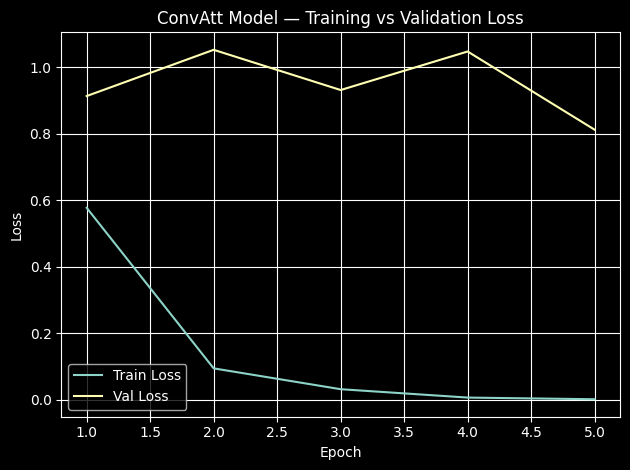

In [40]:
plt.figure()
plt.plot(range(1, len(conv_train_losses) + 1), conv_train_losses, label="Train Loss")
plt.plot(range(1, len(conv_val_losses) + 1), conv_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvAtt Model — Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now let's test the ConvAttModel on impairments it hasn't been trained on, to see how it generalizes compared to the base attention model.

In [41]:
run_scheme_test(generator=initial_generator, model=conv_model, scheme="16QAM", length=128, seed=22, impairments=["noise"], device=device, conv=True, n_samples=100)
run_scheme_test(generator=initial_generator, model=conv_model, scheme="16QAM", length=128, seed=22, impairments=["interfere"], device=device, conv=True, n_samples=100)
run_scheme_test(generator=initial_generator, model=conv_model, scheme="16QAM", length=128, seed=22, impairments=["filter"], device=device, conv=True, n_samples=100)

16QAM Test (noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     101000 010001 110011 000101 1000
Bit Error Rate 0.3536635621857743
--------------------------------------------------
16QAM Test (interfere) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     111001 011001 111010 000101 1010
Bit Error Rate 0.3336024585894364
--------------------------------------------------
16QAM Test (filter) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     110010 110011 111000 111000 0100
Bit Error Rate 0.3452065482035485
--------------------------------------------------


These are better base rates than we saw before. Note as well that we only trained for 5 epochs.

Now train the ConvAttModel on each impairment type, using the same concat + split approach as before.

In [42]:
conv_noisy_model, _, _ = train(model=ConvAttModel(), train_dataloader=data.DataLoader(Subset(noise_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(noise_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device, conv=True)
conv_interfered_model, _, _ = train(model=ConvAttModel(), train_dataloader=data.DataLoader(Subset(interfere_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(interfere_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device, conv=True)
conv_filtered_model, _, _ = train(model=ConvAttModel(), train_dataloader=data.DataLoader(Subset(filter_combined, train_idx), batch_size=64, shuffle=True), val_dataloader=data.DataLoader(Subset(filter_combined, val_idx), batch_size=64, shuffle=False), epochs=15, device=device, conv=True)

Epoch 1/15 | LR: 0.000989 | Training Loss: 2.3096 | Validation Loss: 1.1648 | Validation Accuracy: 0.7571
Epoch 2/15 | LR: 0.000957 | Training Loss: 0.9276 | Validation Loss: 0.6423 | Validation Accuracy: 0.8492
Epoch 3/15 | LR: 0.000905 | Training Loss: 0.6140 | Validation Loss: 0.4937 | Validation Accuracy: 0.8802
Epoch 4/15 | LR: 0.000835 | Training Loss: 0.4982 | Validation Loss: 0.4377 | Validation Accuracy: 0.8861
Epoch 5/15 | LR: 0.000750 | Training Loss: 0.4539 | Validation Loss: 0.4084 | Validation Accuracy: 0.8868
Epoch 6/15 | LR: 0.000655 | Training Loss: 0.4338 | Validation Loss: 0.4015 | Validation Accuracy: 0.8869
Epoch 7/15 | LR: 0.000552 | Training Loss: 0.4233 | Validation Loss: 0.3915 | Validation Accuracy: 0.8884
Epoch 8/15 | LR: 0.000448 | Training Loss: 0.4149 | Validation Loss: 0.3860 | Validation Accuracy: 0.8882
Epoch 9/15 | LR: 0.000345 | Training Loss: 0.4101 | Validation Loss: 0.3801 | Validation Accuracy: 0.8878
Epoch 10/15 | LR: 0.000250 | Training Loss: 0.

Test the impairment-trained ConvAttModels on their respective impairments.

In [43]:
run_scheme_test(generator=initial_generator, model=conv_noisy_model, scheme="16QAM", length=128, seed=22, impairments=["noise"], device=device, conv=True, n_samples=100)
run_scheme_test(generator=initial_generator, model=conv_interfered_model, scheme="16QAM", length=128, seed=22, impairments=["interfere"], device=device, conv=True, n_samples=100)
run_scheme_test(generator=initial_generator, model=conv_filtered_model, scheme="16QAM", length=128, seed=22, impairments=["filter"], device=device, conv=True, n_samples=100)

16QAM Test (noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1000 0100 1101 0010 1000 0010 01
Bit Error Rate 0.01255859375
--------------------------------------------------
16QAM Test (interfere) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1000 0100 1101 0010 1000 0010 01
Bit Error Rate 0.0488671875
--------------------------------------------------
16QAM Test (filter) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1000 0100 1101 0010 1000 0010 01
Decoded Signal Symbols (32 MSBs):     1000 1100 0001 0111 1101 0111 01
Bit Error Rate 0.2133984375
--------------------------------------------------


### Conv Initial Results
We see a HUGE improvement here for the filtered symbols. The convolutional layers are able to learn to separate the inter-symbol interference caused by the low-pass filter, allowing the attention layers to make much more accurate predictions. The noise and interference performance stays relatively the same, although their bit error rates were remarkably low to begin with. Overall, adding convolutional layers before the attention mechanism significantly enhances the model's ability to handle channel impairments, especially those that cause local mixing of symbols.

Now that we have a proof of concept, we will define one final model with increased parameters and regularization, and train it on a much larger dataset with all impairments included, hoping to further reduce bit error rates across the board. Previously, we'd only trained specialized models: one for noise, one for interference, and one for filtering. However, the goal is to hande all three with a single model. This will require a larger, more expressive model and a larger training dataset that includes all impairments in various strengths to encourage generalization.

### ConvAttLarge: Scaled-Up Model

A deeper, wider version of the ConvAttModel with:
- 4 conv layers (2→128→128→256→256) with residual connections
- 4 transformer blocks with embed_dim=256, 8 heads, FFN dim=1024
- Standard dropout (0.1) in attention, FFN, and after conv layers
- More parameters for greater expressiveness

In [56]:
class ConvAttLarge(nn.Module):
    def __init__(self, d_model=128, n_heads=8, ffn_dim=512, num_transformer_blocks=3, dropout=0.2):
        super().__init__()

        # conv frontend: 3 layers
        self.conv1 = nn.Conv1d(2, 64, kernel_size=5, padding="same")
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=5, padding="same")
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, d_model, kernel_size=5, padding="same")
        self.bn3 = nn.BatchNorm1d(d_model)

        self.conv_dropout = nn.Dropout(dropout)
        self.gelu = nn.GELU()

        # transformer blocks
        self.transformer_blocks = nn.ModuleList()
        for _ in range(num_transformer_blocks):
            self.transformer_blocks.append(nn.ModuleDict({
                "attn": nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True, dropout=dropout),
                "ln1": nn.LayerNorm(d_model),
                "ffn": nn.Sequential(
                    nn.Linear(d_model, ffn_dim),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(ffn_dim, d_model),
                    nn.Dropout(dropout),
                ),
                "ln2": nn.LayerNorm(d_model),
            }))

        self.output = nn.Linear(d_model, 86)

    def forward(self, x):
        # Conv frontend: (B, 2, L) -> (B, d_model, L)
        x = self.gelu(self.bn1(self.conv1(x)))
        x = self.conv_dropout(x)

        r = x
        x = self.gelu(self.bn2(self.conv2(x)))
        x = self.conv_dropout(x) + r  # residual

        x = self.gelu(self.bn3(self.conv3(x)))
        x = self.conv_dropout(x)

        # (B, d_model, L) -> (B, L, d_model)
        x = x.permute(0, 2, 1)

        # transformer blocks
        for block in self.transformer_blocks:
            x = block["ln1"](x + block["attn"](x, x, x)[0])
            x = block["ln2"](x + block["ffn"](x))

        return self.output(x)

print(f"ConvAttLarge parameters: {sum(p.numel() for p in ConvAttLarge().parameters()):,}")

ConvAttLarge parameters: 668,758


### Large-Scale Training

Generate a much larger dataset with longer signal lengths (256 symbols per sequence, 10,000 samples). Create impaired copies for all three impairment types, concatenate everything together (clean + noisy + interfered + filtered), and split into train/val. Train for 100 epochs with best-model checkpointing.

In [70]:
large_generator = IQGenerator(seed=77)
large_dataset = large_generator.generate_dataset(num_samples=5000, length=128, seed=100)
large_interference = large_generator.generate_dataset(num_samples=5000, length=128, seed=200)

# generate multiple impaired copies at varying strengths
noisy_datasets = [add_noise(large_dataset, snr_db=snr) for snr in [5, 10, 15, 20]]
interfered_datasets = [add_interference(large_dataset, large_interference, interference_ratio=r) for r in [0.05, 0.1, 0.2, 0.3]]
filtered_dataset = apply_low_pass_filter(large_dataset)

# fully messed up: noise -> interference -> filter (random strengths)
messed_up = add_noise(large_dataset)
messed_up = add_interference(messed_up, large_interference)
messed_up = apply_low_pass_filter(messed_up)

# combine: clean + 4 noise levels + 4 interference levels + filtered + fully messed up
large_combined = ConcatDataset([large_dataset] + noisy_datasets + interfered_datasets + [filtered_dataset, messed_up])

large_train_idx, large_val_idx = train_test_split(range(len(large_combined)), test_size=0.1, random_state=42)

large_train_loader = data.DataLoader(Subset(large_combined, large_train_idx), batch_size=64, shuffle=True)
large_val_loader = data.DataLoader(Subset(large_combined, large_val_idx), batch_size=64, shuffle=False)

print(f"Training samples: {len(large_train_idx)}, Validation samples: {len(large_val_idx)}")

Training samples: 49500, Validation samples: 5500


In [46]:
large_model, large_train_losses, large_val_losses = train(
    model=ConvAttLarge(),
    train_dataloader=large_train_loader,
    val_dataloader=large_val_loader,
    epochs=30,
    device=device,
    conv=True,
    best_model=True,
)

Epoch 1/30 | LR: 0.000997 | Training Loss: 0.9831 | Validation Loss: 0.6335 | Validation Accuracy: 0.8028 *best*
Epoch 2/30 | LR: 0.000989 | Training Loss: 0.7167 | Validation Loss: 0.6065 | Validation Accuracy: 0.8046 *best*
Epoch 3/30 | LR: 0.000976 | Training Loss: 0.6640 | Validation Loss: 0.5902 | Validation Accuracy: 0.8086 *best*
Epoch 4/30 | LR: 0.000957 | Training Loss: 0.6272 | Validation Loss: 0.5719 | Validation Accuracy: 0.8114 *best*
Epoch 5/30 | LR: 0.000933 | Training Loss: 0.6028 | Validation Loss: 0.5790 | Validation Accuracy: 0.8139 *best*
Epoch 6/30 | LR: 0.000905 | Training Loss: 0.5834 | Validation Loss: 0.5784 | Validation Accuracy: 0.8173 *best*
Epoch 7/30 | LR: 0.000872 | Training Loss: 0.5743 | Validation Loss: 0.5908 | Validation Accuracy: 0.8155
Epoch 8/30 | LR: 0.000835 | Training Loss: 0.5632 | Validation Loss: 0.5503 | Validation Accuracy: 0.8199 *best*
Epoch 9/30 | LR: 0.000794 | Training Loss: 0.5532 | Validation Loss: 0.5756 | Validation Accuracy: 0.81

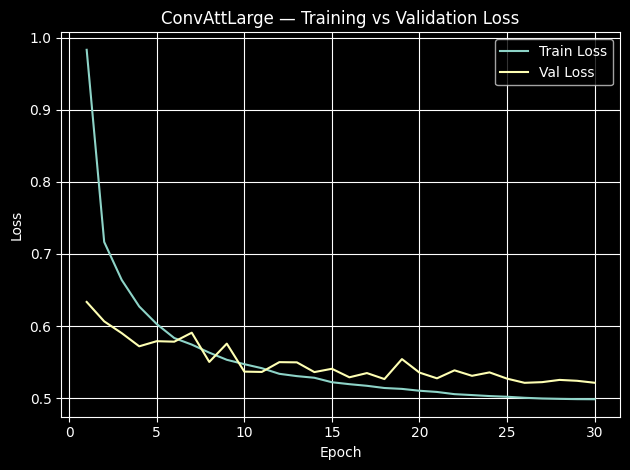

In [47]:
plt.figure()
plt.plot(range(1, len(large_train_losses) + 1), large_train_losses, label="Train Loss")
plt.plot(range(1, len(large_val_losses) + 1), large_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvAttLarge — Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Large Model Results

Test the trained ConvAttLarge on all modulation schemes with each impairment type.

In [48]:
for scheme in ["BPSK", "QPSK", "16QAM", "64QAM"]:
    run_scheme_test(generator=large_generator, model=large_model, scheme=scheme, length=128, seed=50, impairments=[], device=device, conv=True, n_samples=100)

for scheme in ["BPSK", "QPSK", "16QAM", "64QAM"]:
    run_scheme_test(generator=large_generator, model=large_model, scheme=scheme, length=128, seed=50, impairments=["noise"], device=device, conv=True, n_samples=100)

for scheme in ["BPSK", "QPSK", "16QAM", "64QAM"]:
    run_scheme_test(generator=large_generator, model=large_model, scheme=scheme, length=128, seed=50, impairments=["interfere"], device=device, conv=True, n_samples=100)

for scheme in ["BPSK", "QPSK", "16QAM", "64QAM"]:
    run_scheme_test(generator=large_generator, model=large_model, scheme=scheme, length=128, seed=50, impairments=["filter"], device=device, conv=True, n_samples=100)

BPSK Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 
Decoded Signal Symbols (32 MSBs):     1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 
Bit Error Rate 0.0
--------------------------------------------------
QPSK Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 10 10 11 11 10 11 01 11 10 00 01
Decoded Signal Symbols (32 MSBs):     10 10 11 11 10 11 01 11 10 00 01
Bit Error Rate 0.0
--------------------------------------------------
16QAM Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 1001 1000 1110 1011 1000 1111 00
Decoded Signal Symbols (32 MSBs):     1001 1000 1110 1011 1000 1111 00
Bit Error Rate 0.0
--------------------------------------------------
64QAM Test (No noise) — 100 sample(s)
Transmitted Signal Symbols (32 MSBs): 101010 101001 111100 101111 1010
Decoded Signal Symbols (32 MSBs):     101010 101001 111100 101111 1010
Bit Error Rate 0.0
--------------------------------------------------
BP

### Overall Results
The convolutional layers help to separate mixed symbols caused by filtering, while the attention mechanism allows the model to learn complex relationships in the data. Training on a diverse set of impairments also helps the model generalize better to unseen conditions. This allows us to achieve decently low bit error rates across the board despite being trained on multiple types of impairments. The model shows good generalizing capabilities, doing everything somewhat well rather than excelling at just one thing and failing at others. BPSK and QPSK perform exceptionally well, with very low bit error rates even under impairments. 64QAM also performs decently, although it is more affected by noise and interference due to its denser constellation.

Note, however, that 16QAM struggles more than other schemes when it comes to bit error rate. This is likely because 16QAM has constellation points close to 64QAM; with noise, interference, and filtering, the model may predict a symbol as 64QAM, shifting the entire output sequence by 2 bits and therefore creating extremely large bit error rates.

In practice, mitigation techniques would be employed to fix this issue. However, due to the nature of the project and wanting to see if a model could learn to decode these signals without any expert knowledge or hand-crafted features, we will leave it as is for now. Future work could include techniques to specifically address this issue, such as adding a post-processing step to correct for systematic shifts in the predicted symbols, or using a more sophisticated loss function that accounts for the structure of the symbol space.

Overall, the final model does surprisingly well at decoding IQ signals across multiple modulation schemes and under various channel impairments, demonstrating the power of combining convolutional layers with attention mechanisms for this type of sequence classification problem.

### Conclusion
I hope you had fun checking this out! It was fun to work on.
-Ryan

### Statement of LLM Usage
* Used LLMs to help clean up the global mapping scheme code and make it slightly more readable.
* Used LLMs to help me figure out how to apply filtering and learn what it is
* Used LLMs to generalize dataset functions (like testing, impairment generation, etc) to support single signals rather than entire dataloaders, which was helpful for testing and modularity
* General learning and documentation